In [1]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from tqdm.notebook import tqdm

In [2]:
data_dir = "/Users/chanb/research/ualberta/hint_rl/data"
all_evals = sorted([
    filename for filename in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, filename)) and filename.startswith("local_eval-")
])

In [3]:
all_evals

['local_eval-deepscaler_no_hint',
 'local_eval-deepscaler_with_hint',
 'local_eval-questa_no_hint',
 'local_eval-questa_no_hint-paper_model',
 'local_eval-questa_no_hint-trained_344_steps',
 'local_eval-questa_with_hint',
 'local_eval-questa_with_hint-paper_model',
 'local_eval-questa_with_hint-trained_344_steps',
 'local_eval-qwen_no_hint',
 'local_eval-qwen_with_hint']

In [4]:
map_names = {
    "local_eval-deepscaler_no_hint": "DeepScaleR",
    "local_eval-deepscaler_with_hint": "DeepScaleR",
    "local_eval-questa_no_hint": "Nemotron1.5B",
    "local_eval-questa_with_hint": "Nemotron1.5B",
    "local_eval-questa_no_hint-paper_model": "QuestA",
    "local_eval-questa_with_hint-paper_model": "QuestA",
    "local_eval-questa_no_hint-trained_344_steps": "QuestA (trained 344 steps reprod.)",
    "local_eval-questa_with_hint-trained_344_steps": "QuestA (trained 344 steps reprod.)",
    "local_eval-qwen_no_hint": "Qwen",
    "local_eval-qwen_with_hint": "Qwen",
}

In [5]:
all_results = dict()

In [6]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [7]:
def pass_k(n_success, n_samples, k_samples):
    pass_k = (
        1 - scipy.special.comb(
            n_samples - n_success,
            k_samples,
            exact=False,
        ) / scipy.special.comb(n_samples, k_samples, exact=False)
    )
    return pass_k

In [8]:
agg_filename = "agg_eval.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        key = map_names[eval_name]
        has_hint = "w/ Hint" if "with_hint" in eval_name else "w/o Hint"
        all_results.setdefault(key, dict())

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key][has_hint] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

  0%|          | 0/10 [00:00<?, ?it/s]

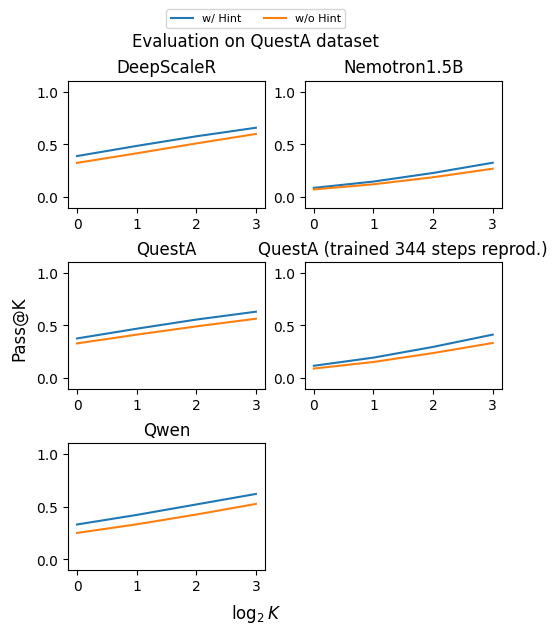

In [26]:
n_rows = math.ceil(len(all_results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.0 * n_rows), layout="constrained")
x_range = np.log2(k_sampless)

axes = axes.flatten()
for ax_i, key in enumerate(all_results):
    curr_result = all_results[key]
    ax = axes[ax_i]

    ax.plot(
        x_range,
        curr_result["w/ Hint"],
        label="w/ Hint" if ax_i == 0 else ""
    )
    ax.plot(
        x_range,
        curr_result["w/o Hint"],
        label="w/o Hint" if ax_i == 0 else ""
    )
    ax.set_title(key)
    ax.set_xticks(x_range)
    ax.set_ylim(-0.1, 1.1)

for ax_i in range(len(all_results), n_rows * n_cols):
    ax = axes[ax_i]
    ax.axis("off")

fig.suptitle("Evaluation on QuestA dataset")
fig.supylabel("Pass@K")
fig.supxlabel("$\\log_2 K$")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [10]:
all_results

{'DeepScaleR': {'w/o Hint': array([0.3246762 , 0.41494488, 0.50881197, 0.59848894]),
  'w/ Hint': array([0.38916622, 0.48513993, 0.57622388, 0.65731247])},
 'Nemotron1.5B': {'w/o Hint': array([0.07332704, 0.12192583, 0.18859764, 0.26929304]),
  'w/ Hint': array([0.08796546, 0.14777195, 0.22918048, 0.32595791])},
 'QuestA': {'w/o Hint': array([0.33007285, 0.41319096, 0.49127284, 0.56395035]),
  'w/ Hint': array([0.37702375, 0.46920052, 0.55587079, 0.6303292 ])},
 'QuestA (trained 344 steps reprod.)': {'w/o Hint': array([0.09194549, 0.15430576, 0.23858608, 0.33405289]),
  'w/ Hint': array([0.1183891 , 0.19547452, 0.29710123, 0.4133837 ])},
 'Qwen': {'w/o Hint': array([0.25033729, 0.33204842, 0.42453936, 0.52509444]),
  'w/ Hint': array([0.33034269, 0.42095829, 0.52016807, 0.61953589])}}